In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions

In [83]:
# Load the data
df = pd.read_csv('https://raw.githubusercontent.com/toplr/SemesterProject_BCIS480/refs/heads/main/telco_churn_data.csv')

# Force 0 for blanks tied with total charges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].str.strip().map({'No': 0, 'Yes': 1})

# This will turn the Contract data into numerical data, which is needed to run knn
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# Preview data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,0,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,1,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,0,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,1,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,0,Yes,Electronic check,70.70,151.65,1


In [117]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 2.1

# Input and output features
X_first = df[["Contract"]]
y_first = df[["Churn"]]

# Scale the input features
scaler_first = StandardScaler()
X_scaled_first = scaler_first.fit_transform(X_first)

# Initialize and fit the model
knn_first = KNeighborsClassifier(n_neighbors=83)
knn_first.fit(X_scaled_first, np.ravel(y_first))

# Predict
knn_first.predict(X_scaled_first)

# Score
score_first = knn_first.score(X_scaled_first, np.ravel(y_first))
print(f"Accuracy score: {score_first:.2%}")

Accuracy score: 73.46%


In [92]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 2.1

#Input and output features
X_new = df[["MonthlyCharges", "TotalCharges"]]
y_new = df[["Churn"]]

# Scale the input features
scaler_second = StandardScaler()
X_scaled_second = scaler.fit_transform(X_new)

# Initialize and fit the model
knn_second = KNeighborsClassifier(n_neighbors=83)
knn_second.fit(X_scaled_second, np.ravel(y_new))

# Predict
knn_second.predict(X_scaled_second)

# The proportion of instances correctly classified
score_second = knn_second.score(X_scaled_second, y_new)
print(f"Accuracy score: {score_second:.2%}")

Accuracy score: 79.58%


In [96]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 2.1

# Input and output features
X_notrain = df[["MonthlyCharges", "TotalCharges", "tenure"]]
y_notrain = df[["Churn"]]

# Scale the input features
scaler_notrain = StandardScaler()
X_scaled_notrain = scaler_notrain.fit_transform(X_notrain)

#Initialize and fit
knn_notrain = KNeighborsClassifier(n_neighbors=83)
knn_notrain.fit(X_scaled_notrain, np.ravel(y_notrain))

# The proportion of instances correctly classified
score_notrain = knn_notrain.score(X_scaled_notrain, np.ravel(y_notrain))
print(f"Accuracy Score: {score_notrain:.2%}")

Accuracy Score: 79.54%


In [116]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 2.1

#Input and output features
X_newest = df[["MonthlyCharges", "TotalCharges", "Contract"]]
y_newest = df[["Churn"]]

# Scale the input features
scaler_third = StandardScaler()
X_scaled_third = scaler_third.fit_transform(X_newest)

# Initialize and fit the model
knn_third = KNeighborsClassifier(n_neighbors=83)
knn_third.fit(X_scaled_third, np.ravel(y_newest))

# Predict
knn_third.predict(X_scaled_third)

# The proportion of instances correctly classified
score_third = knn_third.score(X_scaled_third, y_newest)
print(f"Accuracy Score: {score_third:.2%}")

Accuracy Score: 79.89%


In [118]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 10.2

# Input and output features
X = df[["MonthlyCharges", "TotalCharges", "Contract"]]
y = df[["Churn"]]

# train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit
knn = KNeighborsClassifier(n_neighbors=83)
knn.fit(X_train_scaled, np.ravel(y_train))

# Predict
knnpred = knn.predict(X_test_scaled)

# Accuracy
score = knn.score(X_test_scaled, y_test)
print(f"KNN Accuracy: {score:.2%}")

KNN Accuracy: 80.77%


In [114]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 2.2

# Input and output features
X = df[["MonthlyCharges", "TotalCharges", "Contract"]]
y = df[["Churn"]]

# Initialize and fit
logisticModel = LogisticRegression(penalty=None)
logisticModel.fit(X, np.ravel(y))

# Predict
lrmpred = logisticModel.predict(X)

#Proprotion of instances correctly classified
lr_score = logisticModel.score(X, np.ravel(y))
print(f"LR Accuracy: {lr_score:.2%}")

LR Accuracy: 78.66%


In [115]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 2.2

# Input and output features
X = df[["MonthlyCharges", "TotalCharges", "tenure", "Contract"]]
y = df[["Churn"]]

# Initialize and fit
logisticModel = LogisticRegression(penalty=None)
logisticModel.fit(X, np.ravel(y))

# Predict
lrmpred = logisticModel.predict(X)

#Proprotion of instances correctly classified
lr_score = logisticModel.score(X, np.ravel(y))
print(f"LR Accuracy: {lr_score:.2%}")

LR Accuracy: 78.83%


KNN Model 
 [[4746  428]
 [ 988  881]]
LR Model 
 [[4639  535]
 [ 956  913]]


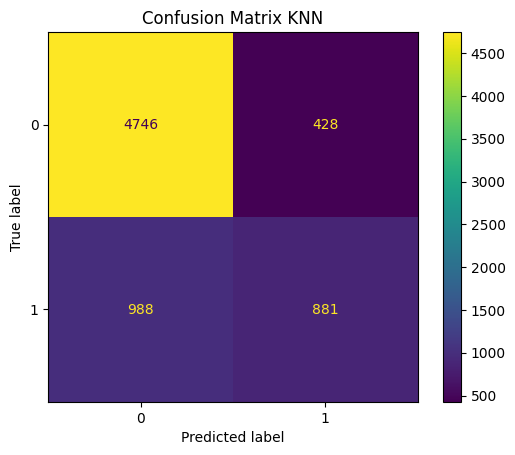

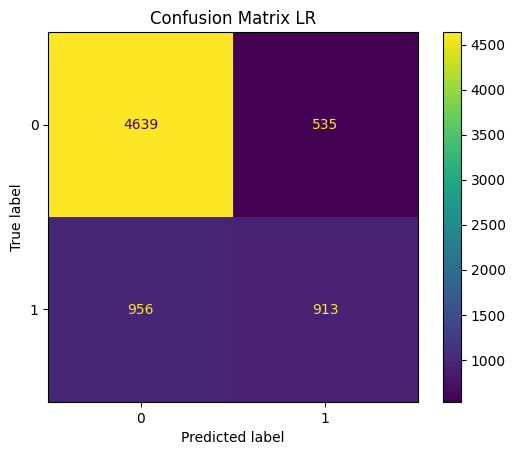

In [82]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 4.2 and 4.5

# Input and output features
X = df[["MonthlyCharges", "TotalCharges", "tenure", "Contract"]]
y = df[["Churn"]]

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Initialize and fit KNN
knn = KNeighborsClassifier(n_neighbors=83)
knn.fit(X, np.ravel(y))

# KNN predict
knnpred = knn.predict(X)

# Initialize and fit LR
lrm = LogisticRegression()
lrm.fit(X, np.ravel(y))

# Logistic regression predict
lrmpred = lrm.predict(X)

# Confusion matrix for each model (NO VISUAL)
print("KNN Model \n", metrics.confusion_matrix(np.ravel(y), knnpred))
print("LR Model \n", metrics.confusion_matrix(np.ravel(y), lrmpred))

# Confusion Matrix for each model (Visual)
# KNN model
ConfusionMatrixDisplay.from_estimator(knn, X, y)
plt.title('Confusion Matrix KNN')
plt.show()

# LR model
ConfusionMatrixDisplay.from_estimator(lrm, X, y)
plt.title('Confusion Matrix LR')
plt.show()

KNN Model 
 [[4755  419]
 [ 993  876]]
LR Model 
 [[4620  554]
 [ 948  921]]


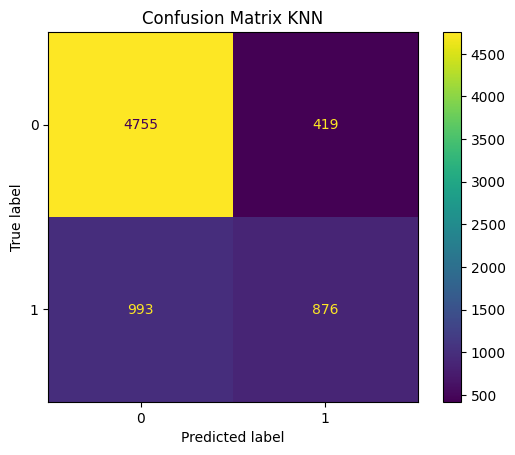

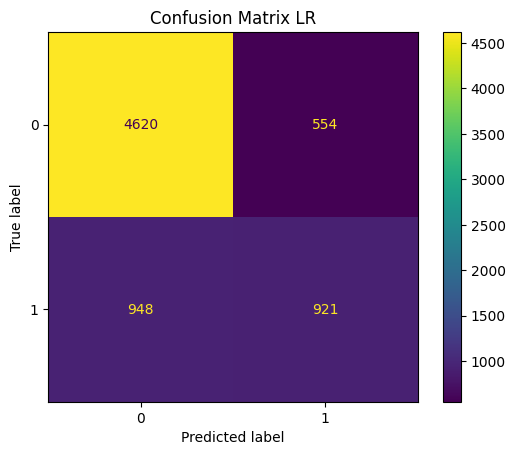

In [120]:
# The logic for this was adapted from
# zyBook "Machine Learning" by Aimee Schwab-McCoy, Section 4.2 and 4.5

# Input and output features
X = df[["MonthlyCharges", "TotalCharges", "Contract"]]
y = df[["Churn"]]

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Initialize and fit KNN
knn = KNeighborsClassifier(n_neighbors=83)
knn.fit(X, np.ravel(y))

# KNN predict
knnpred = knn.predict(X)

# Initialize and fit LR
lrm = LogisticRegression()
lrm.fit(X, np.ravel(y))

# Logistic regression predict
lrmpred = lrm.predict(X)

# Confusion matrix for each model (NO VISUAL)
print("KNN Model \n", metrics.confusion_matrix(np.ravel(y), knnpred))
print("LR Model \n", metrics.confusion_matrix(np.ravel(y), lrmpred))

# Confusion Matrix for each model (Visual)
# KNN model
ConfusionMatrixDisplay.from_estimator(knn, X, y)
plt.title('Confusion Matrix KNN')
plt.show()

# LR model
ConfusionMatrixDisplay.from_estimator(lrm, X, y)
plt.title('Confusion Matrix LR')
plt.show()

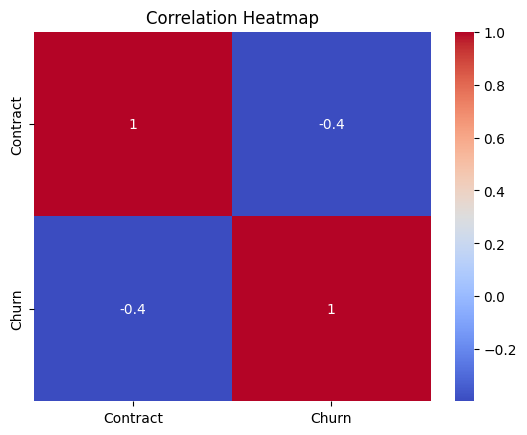

In [121]:
# The correlation heatmaps below are different levels of granularity
# Correlation Heatmap for Contract and Churn
comp = ['Contract', 'Churn']

sns.heatmap(df[comp].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

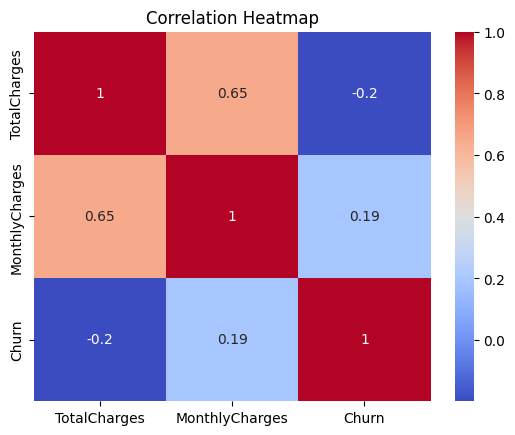

In [57]:
# Correlation Heatmap for Total Charges, Monthly Charges, and Churn
comp = ['TotalCharges', 'MonthlyCharges', 'Churn']

sns.heatmap(df[comp].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

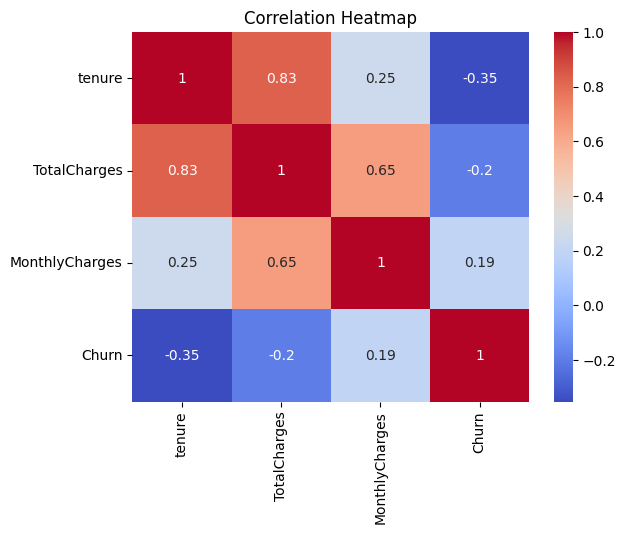

In [10]:
# Correlation Heatmap for Total Charges, Monthly Charges, Tenure, and Churn
comp = ['tenure', 'TotalCharges', 'MonthlyCharges', 'Churn']

sns.heatmap(df[comp].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

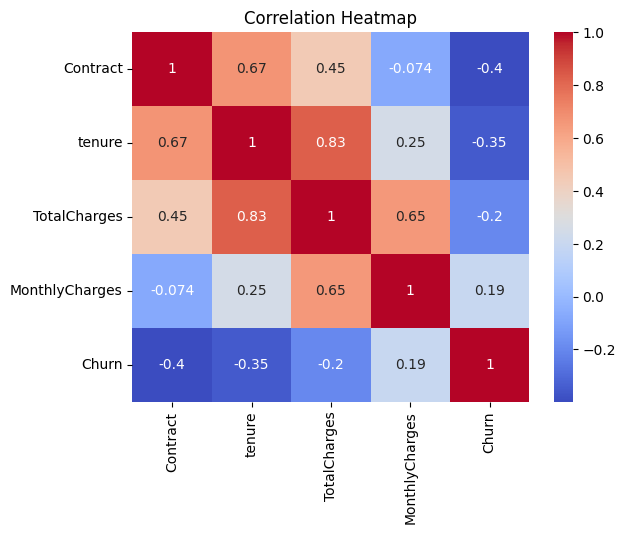

In [ ]:
# Correlation Heatmap for Total Charges, Monthly Charges, Tenure, Contract, and Churn

comp = ['Contract', 'tenure','TotalCharges', 'MonthlyCharges', 'Churn']

sns.heatmap(df[comp].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()